# Catalog inference
---
In this notebook, we move on from individual estimates to running the model over a table of stars.

The stars here are simulated by drawing periods from the model at known ages so that
every star has a ground truth to compare against. 

Feel free to use your own catalog!

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from emberflow import EmberFlow
from emberflow.plots import (CMAP, COLOR, COLOR_ACCENT, FIG_WIDE,
                             LABEL_FS, TICK_FS, set_paper_style)

set_paper_style()

ef = EmberFlow.load()
rng = np.random.default_rng(42)

## Simulating a catalog

We generate a catalog with uniformly generated masses, log-uniform ages from 0.1 to 10 Gyr, and draw one period per star from the learned density $p(\log P_{\mathrm{rot}} \mid \log\tau,\, M_\star,\, \sigma_M)$.

In [2]:
torch.manual_seed(0)

n_stars = 400
mass_err = 0.02

true_mass = rng.uniform(0.15, 0.60, n_stars)
true_age = 10 ** rng.uniform(np.log10(0.1), np.log10(10.0), n_stars)

prot = np.array([
    ef.sample_prot(age_gyr=a, mass=m, mass_err=mass_err, n=1)[0]
    for a, m in zip(true_age, true_mass)
])

stars = pd.DataFrame({
    "prot_days": prot,
    "mass_msun": true_mass,
    "mass_msun_err": np.full(n_stars, mass_err),
})

lo, hi = ef.card["training_range"]["prot_days"]
keep = stars.prot_days.between(lo, hi)
stars = stars[keep].reset_index(drop=True)
true_age = true_age[keep.values]

stars.head()

,prot_days,mass_msun,mass_msun_err
0,16.411636,0.498280,0.02
1,7.056786,0.347495,0.02
2,0.317273,0.536369,0.02
3,1.938658,0.463816,0.02
4,3.210232,0.192380,0.02


## Inference

Recall that `summarize` gives a median and uncertainty interval per star. `age_posteriors` gives the
full grid of possible ages evaluated by the flow.

In [3]:
summary = ef.summarize(stars, level=0.68)
summary.head()

,age_gyr,age_err_lo_gyr,age_err_hi_gyr,level
0,0.865083,0.344062,1.079197,0.68
1,0.659713,0.646370,2.318035,0.68
2,0.120620,0.110218,1.815105,0.68
3,0.011901,0.009871,0.289293,0.68
4,0.156771,0.151876,2.023303,0.68


Text(0, 0.5, 'Posterior density')

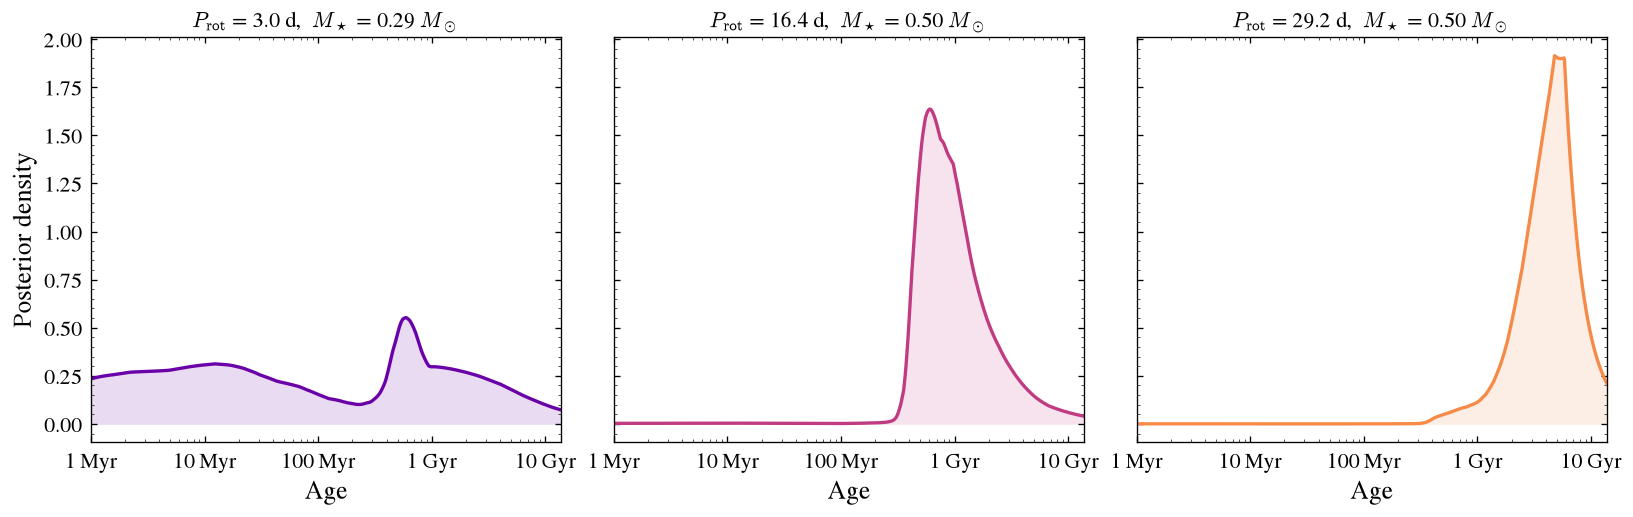

In [4]:
posteriors = ef.age_posteriors(stars)

from emberflow import LOGA_GRID
age_gyr = 10 ** LOGA_GRID / 1000

targets = [(3.0, 0.30), (16.0, 0.50), (28.0, 0.50)]
examples = [int((((stars["prot_days"] - p) / p) ** 2
                 + ((stars["mass_msun"] - m) / 0.05) ** 2).idxmin())
            for p, m in targets]
colors = plt.cm.plasma(np.linspace(0.2, 0.72, 3))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True, layout="constrained")
for ax, idx, c in zip(axes, examples, colors):
    row = stars.iloc[idx]
    ax.plot(age_gyr, posteriors[idx], color=c, lw=2.0)
    ax.fill_between(age_gyr, posteriors[idx], color=c, alpha=0.14)
    ax.set_xscale("log")
    ax.set_xlim(1e-3, 13.8)
    ax.set_xticks([1e-3, 1e-2, 1e-1, 1.0, 10.0])
    ax.set_xticklabels(["1 Myr", "10 Myr", "100 Myr", "1 Gyr", "10 Gyr"])
    ax.set_xlabel("Age", fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_title(rf"$P_{{\rm rot}}$ = {row.prot_days:.1f} d,  $M_\star$ = {row.mass_msun:.2f} $M_\odot$",
                 fontsize=LABEL_FS - 2)
axes[0].set_ylabel("Posterior density", fontsize=LABEL_FS)

## Age recovery and residuals

median offset -0.619 dex


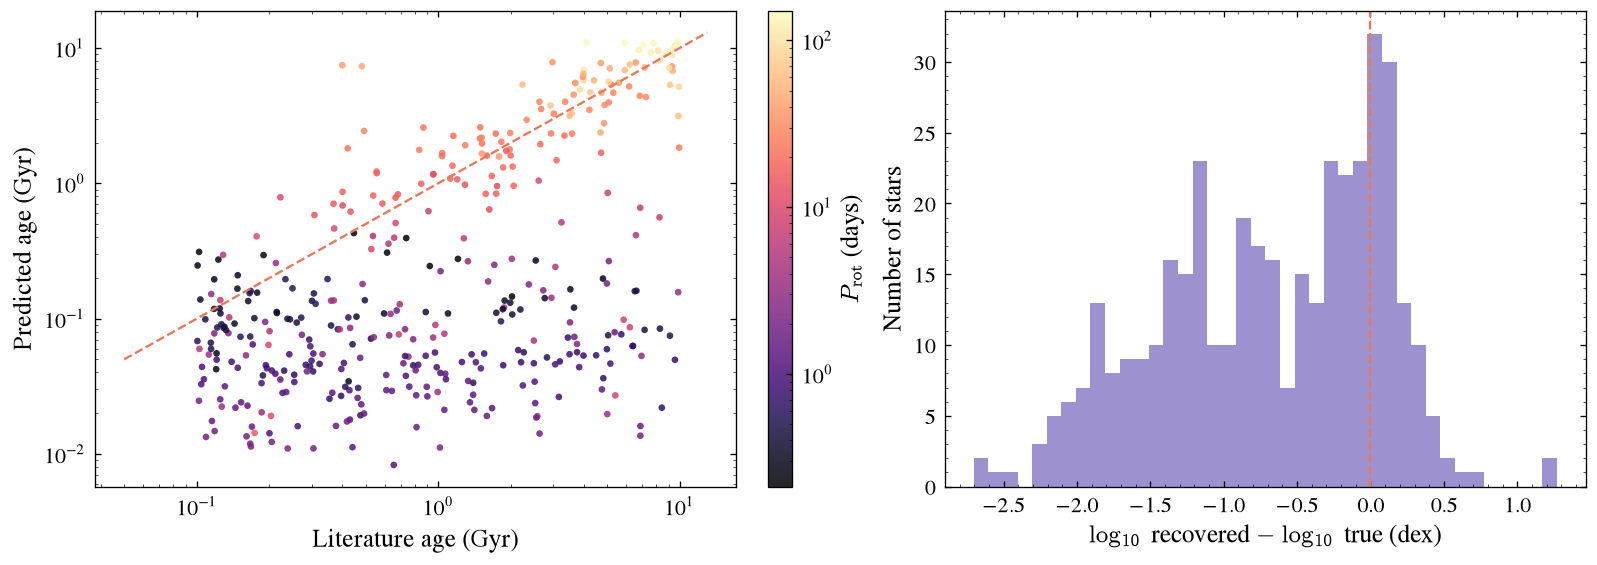

In [5]:
recovered = summary.age_gyr.values
resid = np.log10(recovered) - np.log10(true_age)

fig, axes = plt.subplots(1, 2, figsize=FIG_WIDE, layout="constrained")

sc = axes[0].scatter(true_age, recovered, c=stars.prot_days, s=16,
                     cmap=CMAP, norm="log", alpha=0.85, lw=0)
axes[0].plot([0.05, 13], [0.05, 13], color=COLOR_ACCENT, ls="--", lw=1.4)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Literature age (Gyr)", fontsize=LABEL_FS)
axes[0].set_ylabel("Predicted age (Gyr)", fontsize=LABEL_FS)
axes[0].tick_params(axis="both", which="major", labelsize=TICK_FS)

cbar = fig.colorbar(sc, ax=axes[0])
cbar.set_label(r"$P_{\rm rot}$ (days)", fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)

axes[1].hist(resid, bins=40, color=COLOR, alpha=0.85)
axes[1].axvline(0, color=COLOR_ACCENT, ls="--", lw=1.4)
axes[1].set_xlabel(r"$\log_{10}$ recovered $-$ $\log_{10}$ true (dex)", fontsize=LABEL_FS)
axes[1].set_ylabel("Number of stars", fontsize=LABEL_FS)
axes[1].tick_params(axis="both", which="major", labelsize=TICK_FS)

print(f"median offset {np.median(resid):+.3f} dex")

## 68% and 95% intervals

This shows how often the literature age is within the 68% and 95% intervals.
Ideally, these should be closer to 68% and 95%.

In [6]:
for level in (0.68, 0.95):
    s = ef.summarize(stars, level=level)
    lo_ = s.age_gyr - s.age_err_lo_gyr
    hi_ = s.age_gyr + s.age_err_hi_gyr
    covered = ((true_age >= lo_) & (true_age <= hi_)).mean()
    print(f"{level:.0%} interval contains the truth for {covered:.1%} of stars")

68% interval contains the truth for 66.2% of stars


95% interval contains the truth for 96.0% of stars


## An actual catalog

```python
stars = pd.read_csv("my_stars.csv")
ef.summarize(stars, prot_col="Prot", mass_col="M_star", mass_err_col="M_err")
```